In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.benchmark as benchmark
import torch._dynamo
from torchinfo import summary
import numpy as np
from sklearn.metrics import log_loss

In [22]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

In [23]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [24]:
def train(model, criterion, optimizer):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    epochs = 10000
    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.8f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=2):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(n))

        self.linears = nn.ModuleList()
        for i in range(num_layers):
            self.linears.append(nn.Linear(n * 2 * (2**i), n * (2**i)))

            with torch.no_grad():
                nn.init.zeros_(self.linears[i].weight) # type: ignore
                nn.init.zeros_(self.linears[i].bias)   # type: ignore

        self.final = nn.Linear(n * 2 * (2**num_layers) , 1)

        with torch.no_grad():
            nn.init.zeros_(self.final.weight)
            nn.init.zeros_(self.final.bias)

    def forward(self, x):
        x = x + self.bias

        for linear in self.linears:
            pos = torch.clamp(x, max=0)
            neg = torch.clamp(x, min=0)
            
            new_x = linear(torch.cat([pos, neg], dim=-1)) + x
            x = torch.cat([new_x, x], dim=-1)

        pos = F.relu(x)
        neg = F.relu(-x)

        x = self.final(torch.cat([pos, neg], dim=-1))
        return torch.cat([x, -x], dim=-1)

In [32]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [33]:
@torch._dynamo.explain
def run_model(x):
    return model(x)

run_model(X_train_tensor)

ExplainOutput(graphs=[GraphModule()], graph_count=1, graph_break_count=0, break_reasons=[], op_count=20, ops_per_graph=[[<built-in function add>, <built-in method clamp of type object at 0x138f34350>, <built-in method clamp of type object at 0x138f34350>, <built-in method cat of type object at 0x138f34350>, <built-in function linear>, <built-in function add>, <built-in method cat of type object at 0x138f34350>, <built-in method clamp of type object at 0x138f34350>, <built-in method clamp of type object at 0x138f34350>, <built-in method cat of type object at 0x138f34350>, <built-in function linear>, <built-in function add>, <built-in method cat of type object at 0x138f34350>, <function relu at 0x13c5d2160>, <built-in function neg>, <function relu at 0x13c5d2160>, <built-in method cat of type object at 0x138f34350>, <built-in function linear>, <built-in function neg>, <built-in method cat of type object at 0x138f34350>]], out_guards=[
        global_unspecialized_builtin_nn_module "G['mo

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-1                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                105
│    │    └─Linear: 3-2                  [43152, 14]               406
│    │    └─Linear: 3-3                  [43152, 28]               1,596
│    └─Linear: 2-2                       [43152, 1]                113
Total params: 2,227
Trainable params: 2,227
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 95.80
Input size (MB): 1.21
Forward/backward pass size (MB): 17.26
Params size (MB): 0.01
Estimated Total Size (MB): 18.48
_orig_mod.bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0.], requires_grad=True)
_orig_mod.linears.0.weight
Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

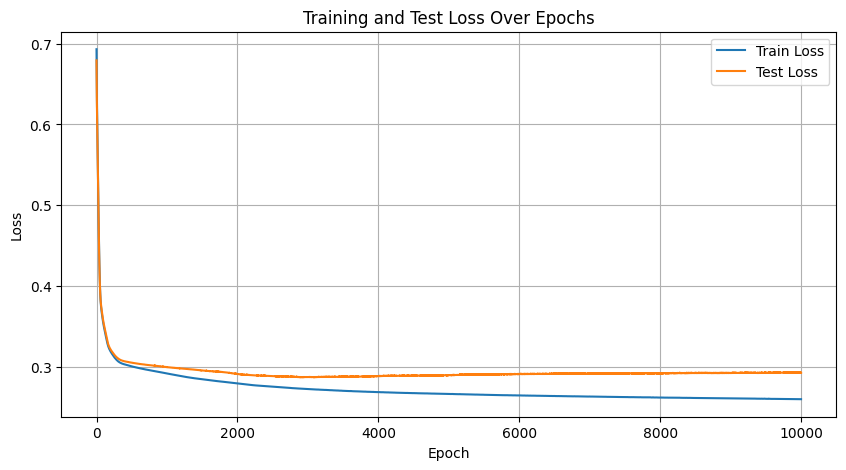

In [9]:
train(model, criterion, optimizer)

In [12]:
torch.set_printoptions(precision=4, sci_mode=False)

for name, param in model.named_parameters():
    print(name)
    print(param)

_orig_mod.bias
Parameter containing:
tensor([-0.2324, -0.1743,  0.2045, -0.0328,  0.2113,  0.0639, -0.2142],
       requires_grad=True)
_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.2419,  0.0356,  0.1093,  0.1834, -0.3615,  0.0243, -0.2166,  0.0373,
          0.0746,  0.3664,  0.0317, -0.1829, -0.1243,  0.0038],
        [-0.1201,  0.1850, -0.0407,  0.0074, -1.1154,  1.1476,  0.0650, -0.1834,
         -0.2264,  0.2218,  0.0341, -0.8197,  0.2453,  0.7900],
        [-0.0667, -0.0110,  0.3125, -0.1614, -0.1042,  0.2506, -0.0999, -0.1357,
          0.0322,  0.2855, -0.0282, -0.0255,  0.2424,  0.0611],
        [-0.3594, -0.0058, -0.0265, -0.0273,  0.1409, -0.0227,  0.1264,  0.2582,
          0.0843,  0.2371, -0.0929, -0.2924,  0.6053, -0.5132],
        [ 0.0812,  0.0353,  0.0498,  0.0758,  0.5215, -0.8727, -0.0308, -0.1969,
          0.1687,  0.2831,  0.0401,  0.6012, -0.6917, -0.0586],
        [ 0.0265,  0.3099,  0.2303, -0.0097, -0.8796,  0.8793, -0.2255, -0.1441,
         

In [19]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                7
│    └─ModuleList: 2-1                   --                        --
│    │    └─Linear: 3-1                  [43152, 7]                105
│    │    └─Linear: 3-2                  [43152, 14]               406
│    └─Linear: 2-2                       [43152, 1]                57
Total params: 575
Trainable params: 575
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 24.51
Input size (MB): 1.21
Forward/backward pass size (MB): 7.59
Params size (MB): 0.00
Estimated Total Size (MB): 8.81
_orig_mod.bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0.], requires_grad=True)
_orig_mod.linears.0.weight
Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [

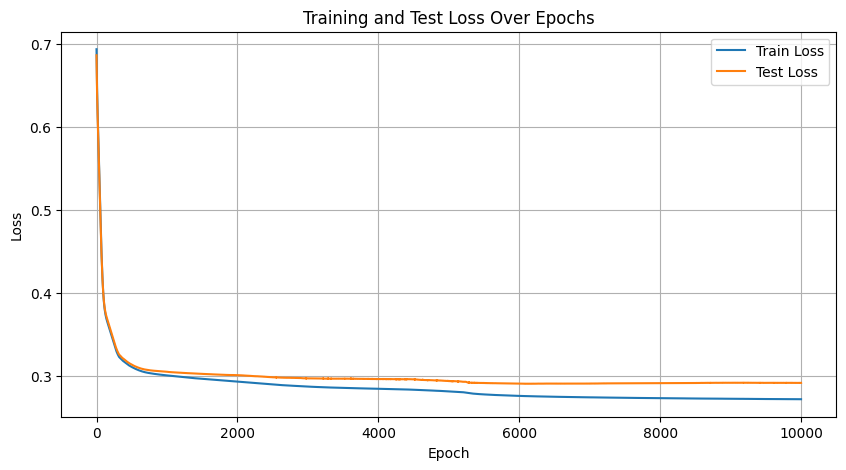

In [20]:
train(model, criterion, optimizer)